In [217]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [218]:
admissions = pd.read_csv("../data/raw/admissions.csv")
patients = pd.read_csv("../data/raw/patients.csv")
diagnoses = pd.read_csv("../data/raw/diagnoses.csv")
billing = pd.read_csv("../data/raw/billing.csv")
hospitals = pd.read_csv("../data/raw/hospitals.csv")

In [219]:
print("Admissions:", admissions.shape)
print("Patients:", patients.shape)
print("Diagnoses:", diagnoses.shape)
print("Billing:", billing.shape)
print("Hospitals:", hospitals.shape)

Admissions: (120000, 17)
Patients: (86400, 8)
Diagnoses: (271341, 6)
Billing: (120000, 6)
Hospitals: (33, 6)


In [220]:
admissions.head()

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


In [221]:
admissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   admission_id    120000 non-null  str    
 1   patient_id      120000 non-null  str    
 2   admit_date      120000 non-null  str    
 3   discharge_date  120000 non-null  str    
 4   los_days        120000 non-null  int64  
 5   admit_type      120000 non-null  str    
 6   ward_type       120000 non-null  str    
 7   hospital_id     120000 non-null  str    
 8   discharge_type  120000 non-null  str    
 9   num_procedures  120000 non-null  int64  
 10  charlson_index  120000 non-null  int64  
 11  hba1c           120000 non-null  float64
 12  creatinine      120000 non-null  float64
 13  haemoglobin     120000 non-null  float64
 14  systolic_bp     120000 non-null  int64  
 15  readmitted_30d  120000 non-null  int64  
 16  readmitted_7d   120000 non-null  int64  
dtypes: float64(3), int64(

In [222]:
admissions.describe(include="all")

,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
count,120000,120000,120000,120000,120000.000000,120000,120000,120000,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
unique,120000,64873,3652,3677,NaN,3,4,33,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,bcb311d6-0808-498f-8ae1-11abe1fbc08e,dd0ca7f5-a2e4-4077-8602-49690edaca7e,2019-07-06,2020-07-01,NaN,Emergency,General,a86650ea-3517-4285-bc11-ffa2085a8df2,Recovered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,10,56,56,NaN,66540,76768,3736,87420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,6.852708,NaN,NaN,NaN,NaN,1.523742,1.894858,5.869862,1.070463,11.840079,134.628075,0.118417,0.008383
std,NaN,NaN,NaN,NaN,5.708269,NaN,NaN,NaN,NaN,1.542197,1.610380,1.061662,0.896135,2.171929,20.756544,0.323102,0.091176
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,4.000000,0.400000,4.000000,70.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,5.300000,0.770000,10.400000,120.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,5.700000,0.910000,11.900000,134.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,2.000000,3.000000,6.100000,1.100000,13.300000,148.000000,0.000000,0.000000


In [223]:
admissions.columns

Index(['admission_id', 'patient_id', 'admit_date', 'discharge_date',
       'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type',
       'num_procedures', 'charlson_index', 'hba1c', 'creatinine',
       'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d'],
      dtype='str')

In [224]:
admissions.isnull().sum()

admission_id      0
patient_id        0
admit_date        0
discharge_date    0
los_days          0
admit_type        0
ward_type         0
hospital_id       0
discharge_type    0
num_procedures    0
charlson_index    0
hba1c             0
creatinine        0
haemoglobin       0
systolic_bp       0
readmitted_30d    0
readmitted_7d     0
dtype: int64

In [225]:
admissions.duplicated().sum()

np.int64(0)

In [226]:
admissions["admit_type"].value_counts()

admit_type
Emergency    66540
Elective     37853
OPD          15607
Name: count, dtype: int64

In [227]:
admissions["ward_type"].value_counts()

ward_type
General    76768
ICU        20833
HDU        15907
NICU        6492
Name: count, dtype: int64

In [228]:
admissions["discharge_type"].value_counts()

discharge_type
Recovered    87420
LAMA         15429
Referred      9738
Expired       7413
Name: count, dtype: int64

In [229]:
billing.head()

,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room
3,32f41176-c088-4e9a-aa81-ae40f91b912a,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,72588,0,72588,Lab
4,cf80fba9-7fec-4b2e-b548-037a43dcf93c,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,9510,0,9510,Lab


In [230]:
billing.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   bill_id            120000 non-null  str  
 1   admission_id       120000 non-null  str  
 2   total_cost_inr     120000 non-null  int64
 3   govt_subsidy_inr   120000 non-null  int64
 4   out_of_pocket_inr  120000 non-null  int64
 5   cost_category      120000 non-null  str  
dtypes: int64(3), str(3)
memory usage: 5.5 MB


In [231]:
billing.describe(include="all")

,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
count,120000,120000,1.200000e+05,1.200000e+05,1.200000e+05,120000
unique,120000,120000,NaN,NaN,NaN,4
top,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,NaN,NaN,NaN,Pharmacy
freq,1,1,NaN,NaN,NaN,36280
mean,NaN,NaN,9.577953e+04,4.760617e+04,4.817336e+04,NaN
std,NaN,NaN,1.955118e+05,1.062371e+05,1.395519e+05,NaN
min,NaN,NaN,6.490000e+02,0.000000e+00,0.000000e+00,NaN
25%,NaN,NaN,1.202300e+04,0.000000e+00,0.000000e+00,NaN
50%,NaN,NaN,3.097050e+04,1.214550e+04,7.636000e+03,NaN
75%,NaN,NaN,8.940700e+04,4.585575e+04,3.334100e+04,NaN


In [232]:
billing.columns

Index(['bill_id', 'admission_id', 'total_cost_inr', 'govt_subsidy_inr',
       'out_of_pocket_inr', 'cost_category'],
      dtype='str')

In [233]:
billing.isnull().sum()

bill_id              0
admission_id         0
total_cost_inr       0
govt_subsidy_inr     0
out_of_pocket_inr    0
cost_category        0
dtype: int64

In [234]:
billing.duplicated().sum()

np.int64(0)

In [235]:
diagnoses.head()

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological
3,754ec3d2-e940-4342-9e1d-d88a9acec626,cc4849fa-b740-487b-beda-3086a18273c0,A15,Pulmonary tuberculosis,2,Infectious
4,f4fa0d7b-0a68-4dd9-b7cf-db15c6bf3812,cc4849fa-b740-487b-beda-3086a18273c0,I48,Atrial fibrillation,3,Cardiovascular


In [236]:
diagnoses.info()

<class 'pandas.DataFrame'>
RangeIndex: 271341 entries, 0 to 271340
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   diag_id        271341 non-null  str  
 1   admission_id   271341 non-null  str  
 2   icd10_code     271341 non-null  str  
 3   diag_desc      271341 non-null  str  
 4   diag_rank      271341 non-null  int64
 5   diag_category  271341 non-null  str  
dtypes: int64(1), str(5)
memory usage: 12.4 MB


In [237]:
diagnoses.describe(include="all")

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
count,271341,271341,271341,271341,271341.000000,271341
unique,271341,120000,34,34,NaN,11
top,3b448b98-6b78-4c7c-94c1-f832581c5052,b1553698-9045-4f6b-a369-708600d6d1d9,E10,Type 1 diabetes mellitus,NaN,Cardiovascular
freq,1,4,12079,12079,NaN,53410
mean,NaN,NaN,NaN,NaN,1.926867,NaN
std,NaN,NaN,NaN,NaN,0.998618,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN
25%,NaN,NaN,NaN,NaN,1.000000,NaN
50%,NaN,NaN,NaN,NaN,2.000000,NaN
75%,NaN,NaN,NaN,NaN,3.000000,NaN


In [238]:
diagnoses.columns

Index(['diag_id', 'admission_id', 'icd10_code', 'diag_desc', 'diag_rank',
       'diag_category'],
      dtype='str')

In [239]:
diagnoses.isnull().sum()

diag_id          0
admission_id     0
icd10_code       0
diag_desc        0
diag_rank        0
diag_category    0
dtype: int64

In [240]:
diagnoses.duplicated().sum()

np.int64(0)

In [241]:
diagnoses["diag_category"].value_counts()

diag_category
Cardiovascular      53410
Endocrine           35491
Respiratory         30648
Infectious          30397
Gastrointestinal    23601
Neoplasm            21776
Injury              17278
Neurological        17111
Genitourinary       16591
Obstetric           12973
Perinatal           12065
Name: count, dtype: int64

In [242]:
billing["cost_category"].value_counts()

cost_category
Pharmacy     36280
Procedure    33536
Room         29988
Lab          20196
Name: count, dtype: int64

In [243]:
hospitals.head()

,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


In [244]:
hospitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   hospital_id  33 non-null     str  
 1   name         33 non-null     str  
 2   state        33 non-null     str  
 3   tier         33 non-null     str  
 4   beds         33 non-null     int64
 5   teaching     33 non-null     bool 
dtypes: bool(1), int64(1), str(4)
memory usage: 1.5 KB


In [245]:
hospitals.describe(include="all")

,hospital_id,name,state,tier,beds,teaching
count,33,33,33,33,33.000000,33
unique,33,26,15,3,NaN,2
top,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Apollo/Manipal (Private) Andhra Pradesh,Andhra Pradesh,tier2,NaN,True
freq,1,4,5,15,NaN,19
mean,NaN,NaN,NaN,NaN,440.454545,NaN
std,NaN,NaN,NaN,NaN,294.238964,NaN
min,NaN,NaN,NaN,NaN,61.000000,NaN
25%,NaN,NaN,NaN,NaN,191.000000,NaN
50%,NaN,NaN,NaN,NaN,423.000000,NaN
75%,NaN,NaN,NaN,NaN,632.000000,NaN


In [246]:
hospitals.columns

Index(['hospital_id', 'name', 'state', 'tier', 'beds', 'teaching'], dtype='str')

In [247]:
hospitals.isnull().sum()

hospital_id    0
name           0
state          0
tier           0
beds           0
teaching       0
dtype: int64

In [248]:
hospitals.duplicated().sum()

np.int64(0)

In [249]:
patients.head()

,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


In [250]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   patient_id         86400 non-null  str  
 1   age                86400 non-null  int64
 2   gender             86400 non-null  str  
 3   state              86400 non-null  str  
 4   bpl_card           86400 non-null  bool 
 5   insurance_type     61685 non-null  str  
 6   comorbidity_count  86400 non-null  int64
 7   prev_admissions    86400 non-null  int64
dtypes: bool(1), int64(3), str(4)
memory usage: 4.7 MB


In [251]:
patients.describe(include="all")

,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
count,86400,86400.000000,86400,86400,86400,61685,86400.000000,86400.000000
unique,86400,NaN,3,15,2,3,NaN,NaN
top,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,NaN,M,Maharashtra,False,Ayushman,NaN,NaN
freq,1,NaN,44190,9633,54790,25967,NaN,NaN
mean,NaN,48.000405,NaN,NaN,NaN,NaN,1.426470,0.896076
std,NaN,21.690553,NaN,NaN,NaN,NaN,1.506211,1.083745
min,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,36.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,NaN,51.000000,NaN,NaN,NaN,NaN,1.000000,1.000000
75%,NaN,63.000000,NaN,NaN,NaN,NaN,2.000000,1.000000


In [252]:
patients.columns

Index(['patient_id', 'age', 'gender', 'state', 'bpl_card', 'insurance_type',
       'comorbidity_count', 'prev_admissions'],
      dtype='str')

In [253]:
patients.isnull().sum()

patient_id               0
age                      0
gender                   0
state                    0
bpl_card                 0
insurance_type       24715
comorbidity_count        0
prev_admissions          0
dtype: int64

In [254]:
patients.duplicated().sum()

np.int64(0)

In [255]:
patients["gender"].value_counts()

gender
M        44190
F        41361
Other      849
Name: count, dtype: int64

In [256]:
patients["insurance_type"].value_counts(dropna=False)

insurance_type
Ayushman    25967
NaN         24715
Private     21372
ESI         14346
Name: count, dtype: int64

Univariate Analysis

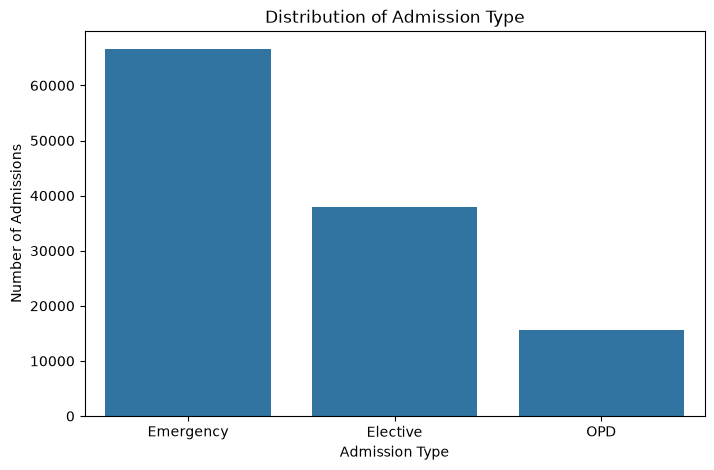

In [257]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=admissions,
    x="admit_type",
    order=admissions["admit_type"].value_counts().index
)

plt.title("Distribution of Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")

plt.show()

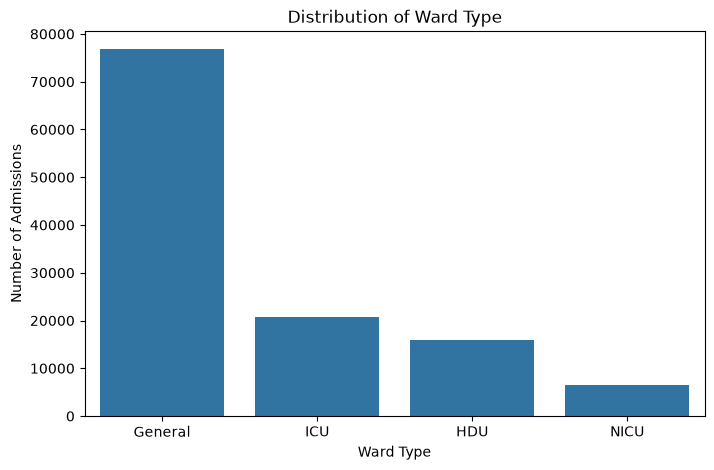

In [258]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=admissions,
    x="ward_type",
    order=admissions["ward_type"].value_counts().index
)

plt.title("Distribution of Ward Type")
plt.xlabel("Ward Type")
plt.ylabel("Number of Admissions")

plt.show()

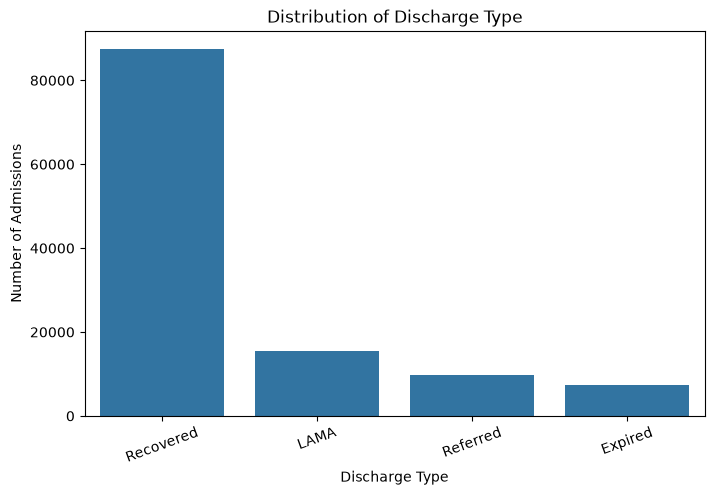

In [259]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=admissions,
    x="discharge_type",
    order=admissions["discharge_type"].value_counts().index
)

plt.title("Distribution of Discharge Type")
plt.xlabel("Discharge Type")
plt.ylabel("Number of Admissions")

plt.xticks(rotation=20)

plt.show()

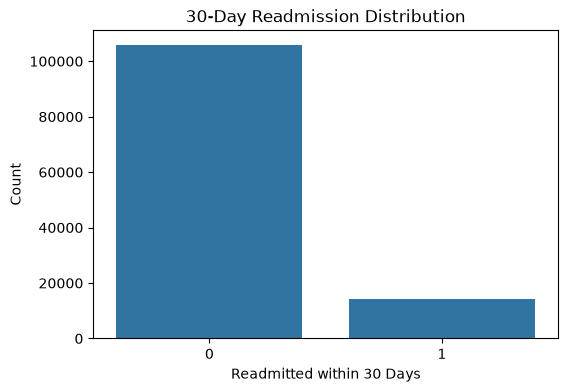

In [260]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=admissions,
    x="readmitted_30d"
)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Count")

plt.show()

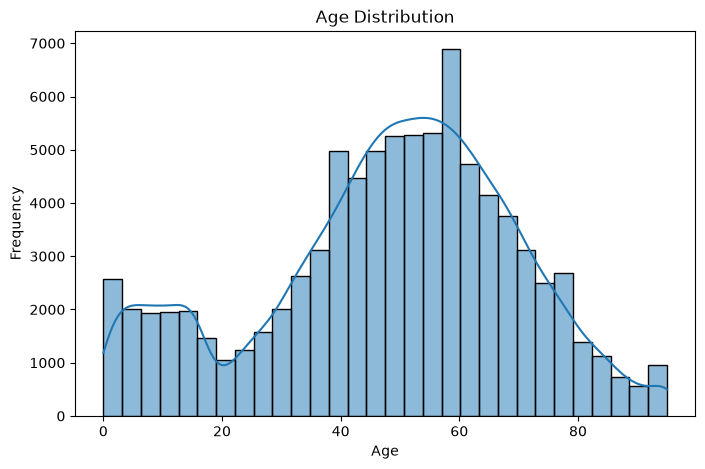

In [261]:
plt.figure(figsize=(8,5))

sns.histplot(
    patients["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

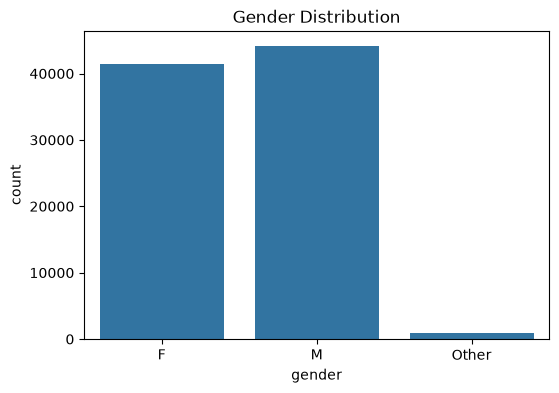

In [262]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=patients,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

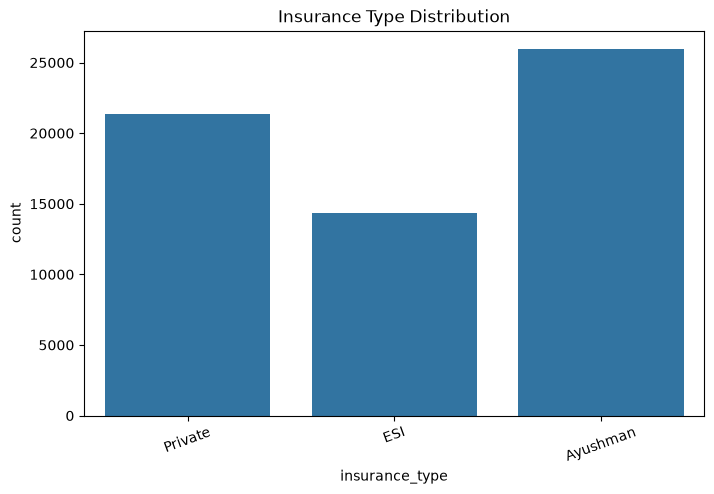

In [263]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=patients,
    x="insurance_type"
)

plt.title("Insurance Type Distribution")

plt.xticks(rotation=20)

plt.show()

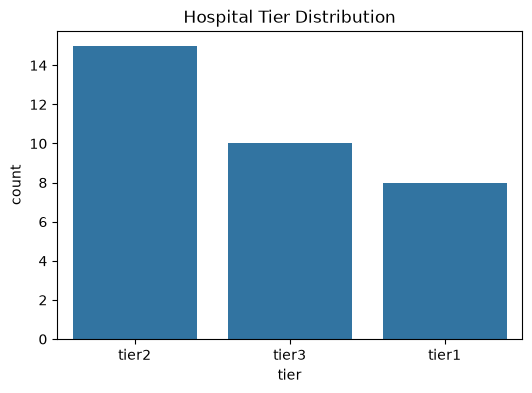

In [264]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=hospitals,
    x="tier"
)

plt.title("Hospital Tier Distribution")

plt.show()

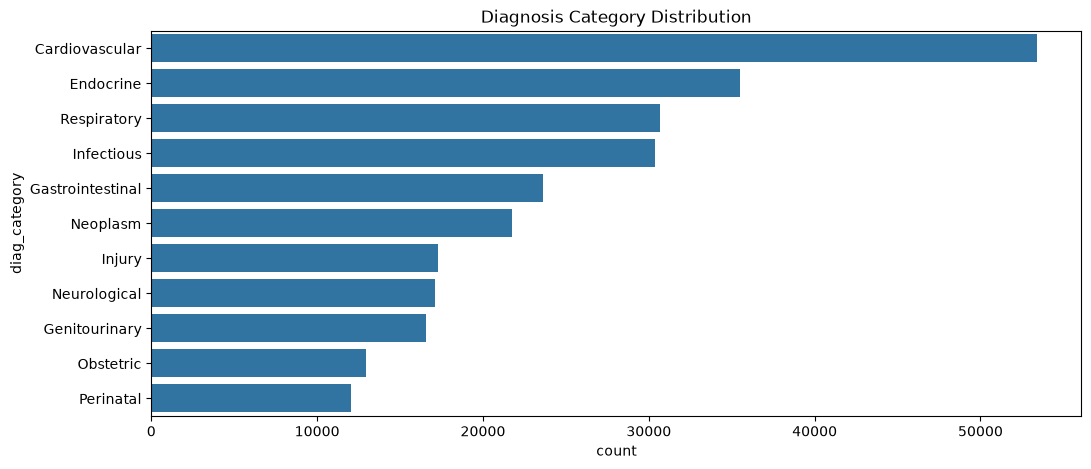

In [265]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=diagnoses,
    y="diag_category",
    order=diagnoses["diag_category"].value_counts().index
)

plt.title("Diagnosis Category Distribution")

plt.show()

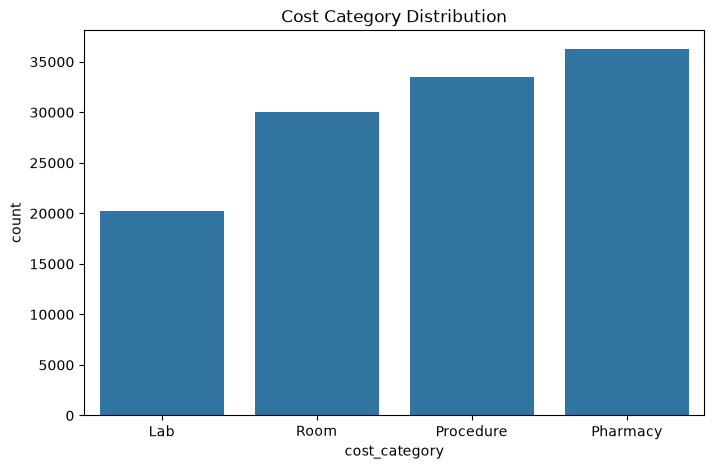

In [266]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=billing,
    x="cost_category"
)

plt.title("Cost Category Distribution")

plt.show()

Numerical Feature Distribution

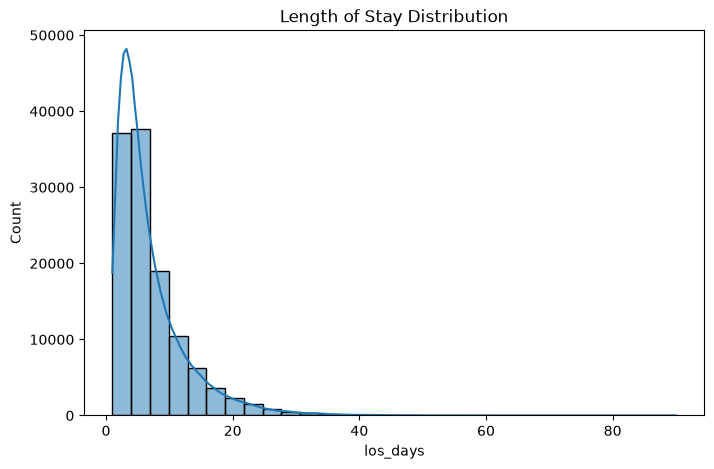

In [267]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["los_days"],
    bins=30,
    kde=True
)

plt.title("Length of Stay Distribution")

plt.show()

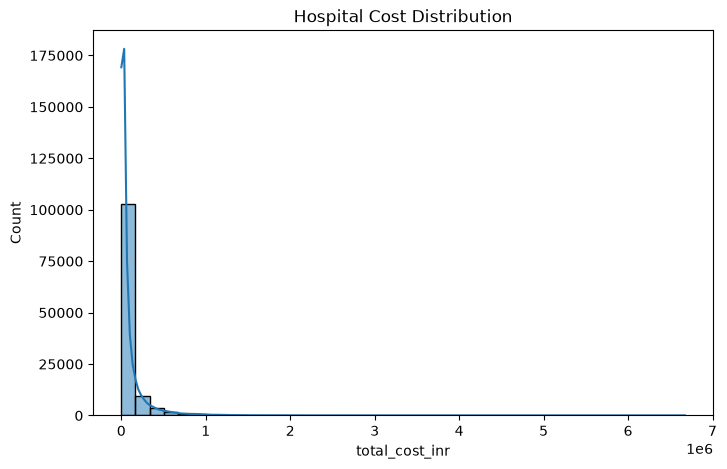

In [268]:
plt.figure(figsize=(8,5))

sns.histplot(
    billing["total_cost_inr"],
    bins=40,
    kde=True
)

plt.title("Hospital Cost Distribution")

plt.show()

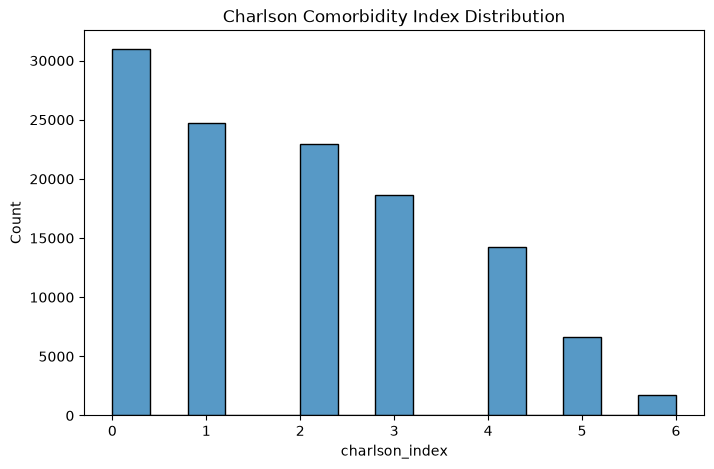

In [269]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["charlson_index"],
    bins=15
)

plt.title("Charlson Comorbidity Index Distribution")

plt.show()

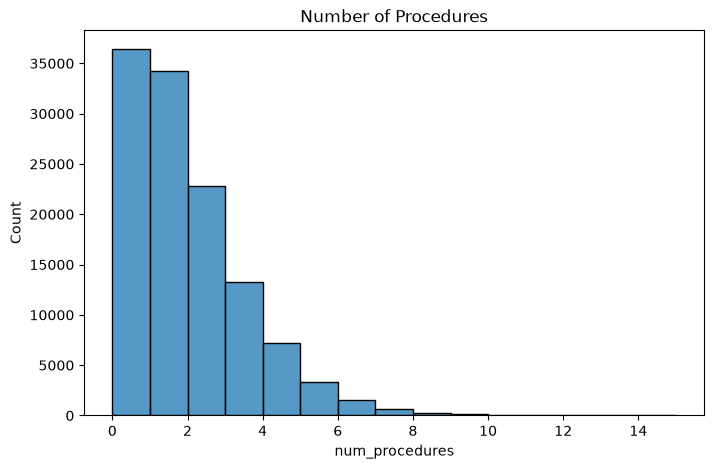

In [270]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["num_procedures"],
    bins=15
)

plt.title("Number of Procedures")

plt.show()

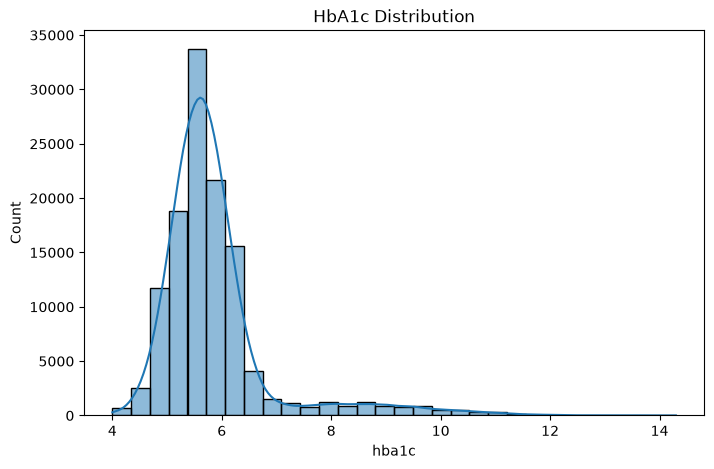

In [271]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["hba1c"],
    bins=30,
    kde=True
)

plt.title("HbA1c Distribution")

plt.show()

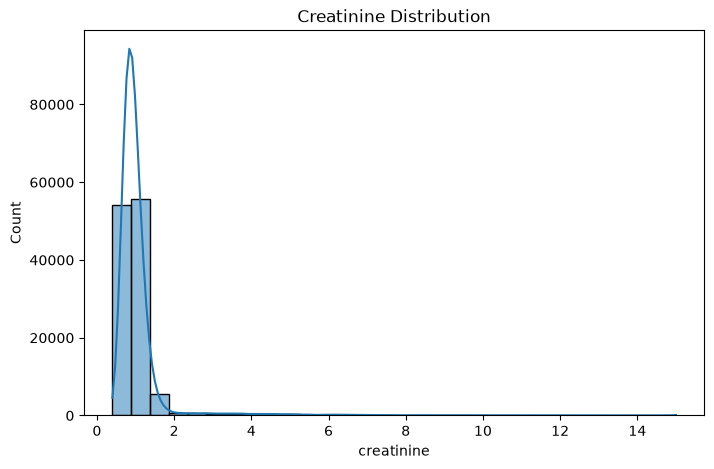

In [272]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["creatinine"],
    bins=30,
    kde=True
)

plt.title("Creatinine Distribution")

plt.show()

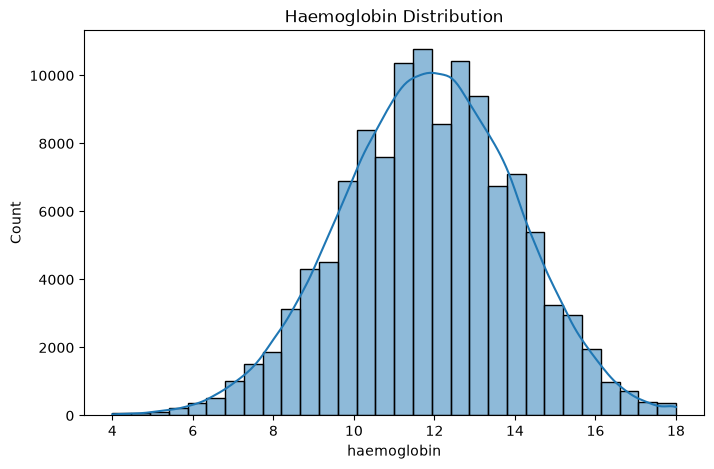

In [273]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["haemoglobin"],
    bins=30,
    kde=True
)

plt.title("Haemoglobin Distribution")

plt.show()

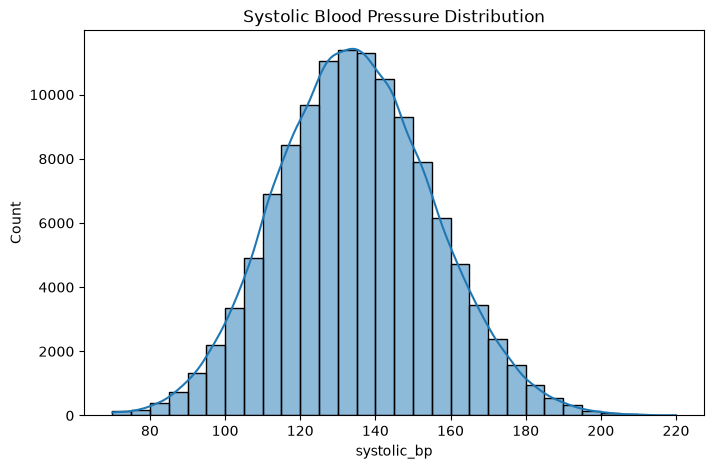

In [274]:
plt.figure(figsize=(8,5))

sns.histplot(
    admissions["systolic_bp"],
    bins=30,
    kde=True
)

plt.title("Systolic Blood Pressure Distribution")

plt.show()

Bivariate Analysis

In [275]:

eda_df = admissions.merge(
    patients,
    on="patient_id",
    how="left"
)

eda_df = eda_df.merge(
    hospitals,
    on="hospital_id",
    how="left"
)

eda_df = eda_df.merge(
    billing,
    on="admission_id",
    how="left"
)

print(eda_df.shape)
eda_df.head()

(120000, 34)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state_x,bpl_card,insurance_type,comorbidity_count,prev_admissions,name,state_y,tier,beds,teaching,bill_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,Government General Hospital Odisha,Odisha,tier2,359,True,68e19242-4126-4a7a-afa2-9e6035cdcffa,18492,16630,1862,Lab
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,b740202e-1d7a-45b4-9575-21b35e219e37,1001,0,1001,Lab
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,Apollo/Manipal (Private) Karnataka,Karnataka,tier1,1018,True,f60fecaa-e769-42ea-bee8-58198bdd1208,59696,48650,11046,Room
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0,56,F,Kerala,False,NaN,0,1,District Hospital Uttar Pradesh,Uttar Pradesh,tier3,191,False,32f41176-c088-4e9a-aa81-ae40f91b912a,72588,0,72588,Lab
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0,69,F,Kerala,False,NaN,2,0,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,cf80fba9-7fec-4b2e-b548-037a43dcf93c,9510,0,9510,Lab


In [276]:
eda_df.rename(
    columns={
        "state_x": "patient_state",
        "state_y": "hospital_state"
    },
    inplace=True
)

In [277]:
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   admission_id       120000 non-null  str    
 1   patient_id         120000 non-null  str    
 2   admit_date         120000 non-null  str    
 3   discharge_date     120000 non-null  str    
 4   los_days           120000 non-null  int64  
 5   admit_type         120000 non-null  str    
 6   ward_type          120000 non-null  str    
 7   hospital_id        120000 non-null  str    
 8   discharge_type     120000 non-null  str    
 9   num_procedures     120000 non-null  int64  
 10  charlson_index     120000 non-null  int64  
 11  hba1c              120000 non-null  float64
 12  creatinine         120000 non-null  float64
 13  haemoglobin        120000 non-null  float64
 14  systolic_bp        120000 non-null  int64  
 15  readmitted_30d     120000 non-null  int64  
 16  readmitted_7d

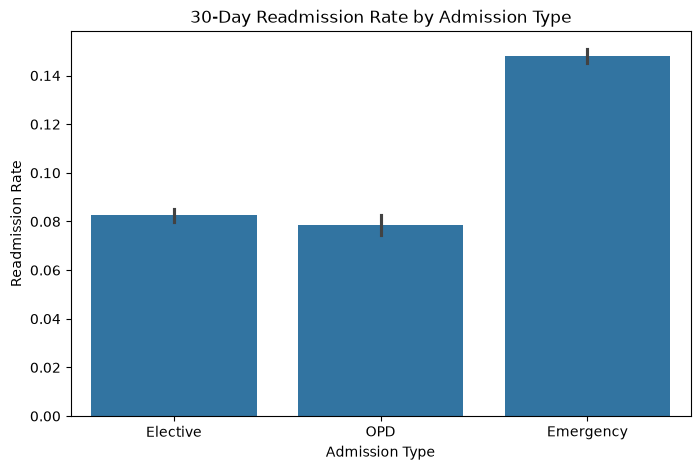

In [278]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="admit_type",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Readmission Rate")

plt.show()

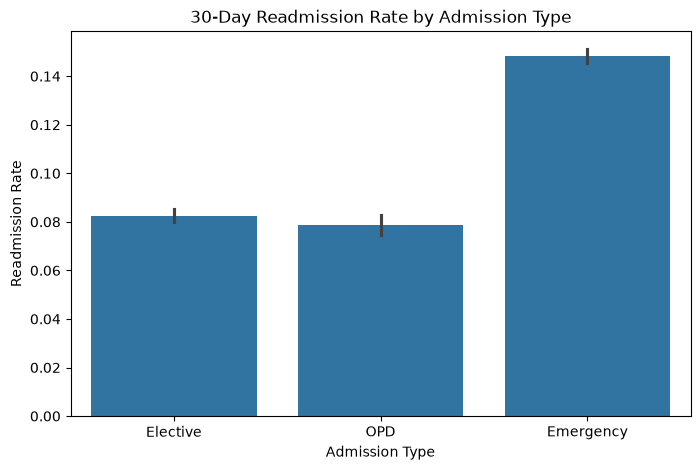

In [279]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="admit_type",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Readmission Rate")

plt.show()

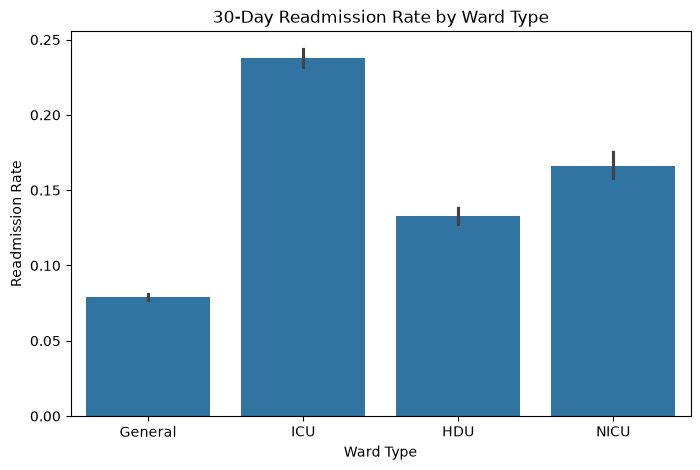

In [280]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="ward_type",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Ward Type")
plt.xlabel("Ward Type")
plt.ylabel("Readmission Rate")

plt.show()

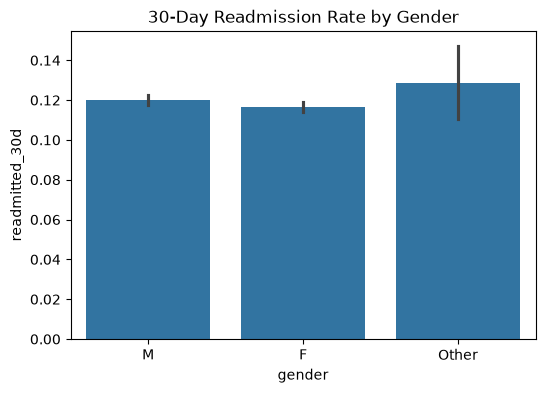

In [281]:

plt.figure(figsize=(6,4))

sns.barplot(
    data=eda_df,
    x="gender",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Gender")

plt.show()

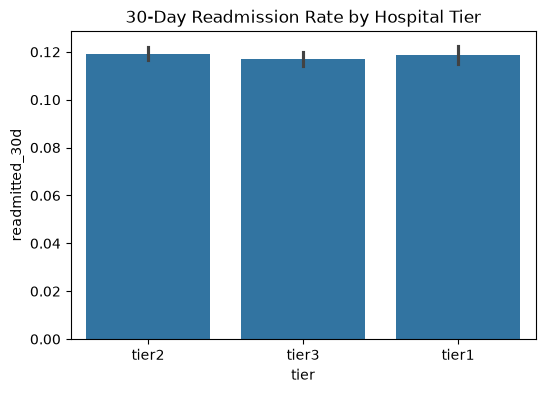

In [282]:

plt.figure(figsize=(6,4))

sns.barplot(
    data=eda_df,
    x="tier",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Hospital Tier")

plt.show()

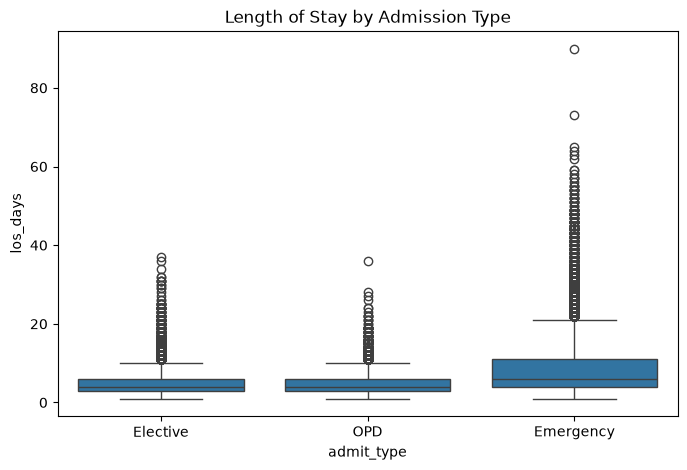

In [283]:

plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="admit_type",
    y="los_days"
)

plt.title("Length of Stay by Admission Type")

plt.show()

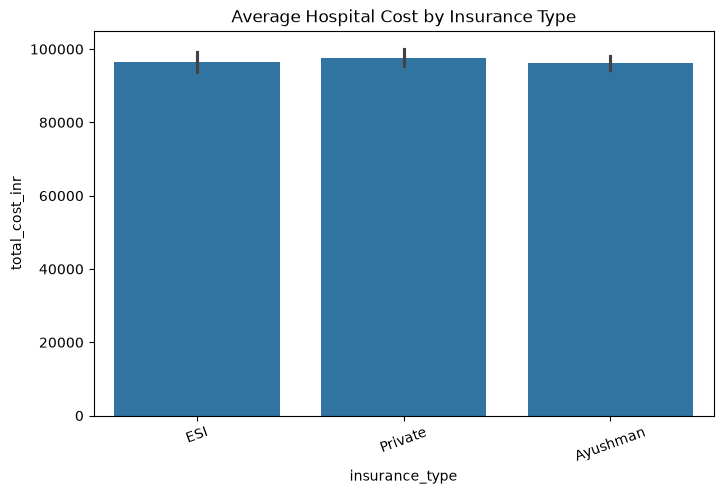

In [284]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="insurance_type",
    y="total_cost_inr",
    estimator=np.mean
)

plt.title("Average Hospital Cost by Insurance Type")

plt.xticks(rotation=20)

plt.show()

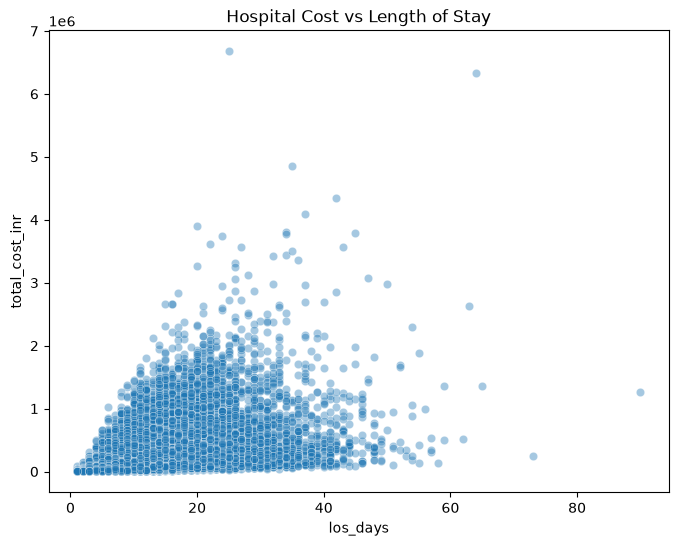

In [285]:

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=eda_df,
    x="los_days",
    y="total_cost_inr",
    alpha=0.4
)

plt.title("Hospital Cost vs Length of Stay")

plt.show()

In [286]:

eda_df["age_group"] = pd.cut(
    eda_df["age"],
    bins=[0,18,35,50,65,100],
    labels=["0-18","19-35","36-50","51-65","65+"],
    include_lowest=True
)

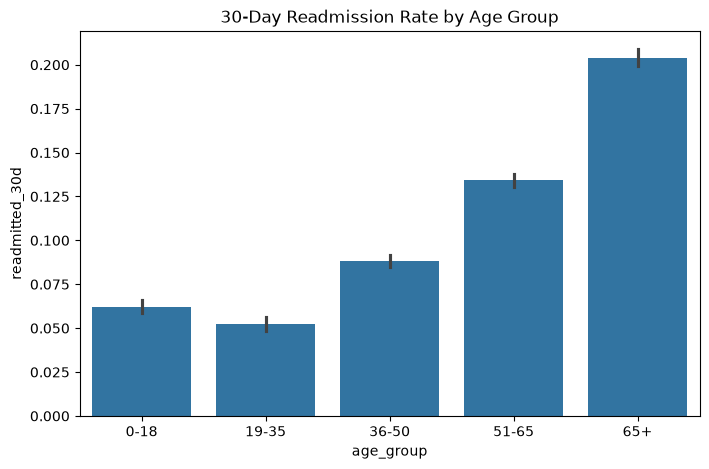

In [287]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="age_group",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Age Group")

plt.show()

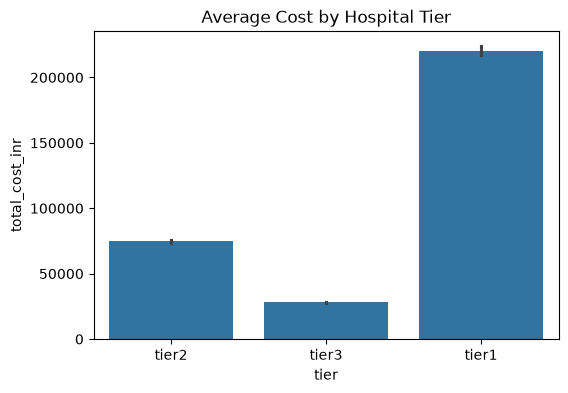

In [288]:

plt.figure(figsize=(6,4))

sns.barplot(
    data=eda_df,
    x="tier",
    y="total_cost_inr",
    estimator=np.mean
)

plt.title("Average Cost by Hospital Tier")

plt.show()

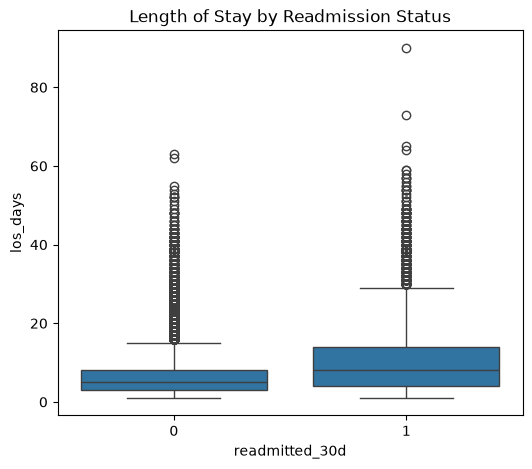

In [289]:

plt.figure(figsize=(6,5))

sns.boxplot(
    data=eda_df,
    x="readmitted_30d",
    y="los_days"
)

plt.title("Length of Stay by Readmission Status")

plt.show()

Correlation Analysis

In [290]:

numerical_df = eda_df.select_dtypes(include=["int64", "float64"])

numerical_df.head()

,los_days,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,comorbidity_count,prev_admissions,beds,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr
0,4,0,0,6.3,0.86,16.2,157,0,0,46,0,0,359,18492,16630,1862
1,1,1,0,5.2,1.23,13.1,156,0,0,31,0,0,67,1001,0,1001
2,5,0,2,5.6,0.67,10.9,130,1,0,53,2,3,1018,59696,48650,11046
3,11,1,2,4.7,1.40,8.8,159,1,0,56,0,1,191,72588,0,72588
4,5,1,5,5.0,0.94,11.3,173,1,0,69,2,0,67,9510,0,9510


In [291]:

corr_matrix = numerical_df.corr()

corr_matrix

,los_days,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,comorbidity_count,prev_admissions,beds,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr
los_days,1.000000,0.167297,0.145957,-0.085518,-0.012357,-0.063159,0.080877,0.218204,0.119882,0.069282,0.115214,0.059319,-0.001621,0.582470,0.462648,0.463838
num_procedures,0.167297,1.000000,0.447379,-0.047991,0.083928,-0.197794,0.187226,0.154993,0.073911,0.325192,0.519477,0.252191,0.004676,0.268368,0.229544,0.201237
charlson_index,0.145957,0.447379,1.000000,0.074738,0.160879,-0.387260,0.293626,0.199160,0.086483,0.728092,0.730800,0.354877,0.000987,0.125683,0.123798,0.081838
hba1c,-0.085518,-0.047991,0.074738,1.000000,-0.040040,-0.005454,-0.044924,-0.015158,-0.010071,0.001088,0.006544,0.003140,-0.001877,-0.082671,-0.068279,-0.063843
creatinine,-0.012357,0.083928,0.160879,-0.040040,1.000000,-0.010326,-0.018887,0.021083,0.002468,0.037435,0.019719,0.010461,-0.001896,-0.004310,0.003503,-0.008705
haemoglobin,-0.063159,-0.197794,-0.387260,-0.005454,-0.010326,1.000000,-0.139604,-0.131524,-0.063473,-0.385072,-0.371489,-0.182750,-0.002508,-0.058753,-0.050079,-0.044189
systolic_bp,0.080877,0.187226,0.293626,-0.044924,-0.018887,-0.139604,1.000000,0.090246,0.043299,0.290683,0.235881,0.111607,-0.004835,0.114658,0.096129,0.087456
readmitted_30d,0.218204,0.154993,0.199160,-0.015158,0.021083,-0.131524,0.090246,1.000000,0.250878,0.156359,0.217649,0.158402,0.002330,0.167046,0.134149,0.131907
readmitted_7d,0.119882,0.073911,0.086483,-0.010071,0.002468,-0.063473,0.043299,0.250878,1.000000,0.068673,0.108300,0.082584,0.001467,0.092260,0.066794,0.078408
age,0.069282,0.325192,0.728092,0.001088,0.037435,-0.385072,0.290683,0.156359,0.068673,1.000000,0.569032,0.277830,0.001608,0.087141,0.078954,0.061979


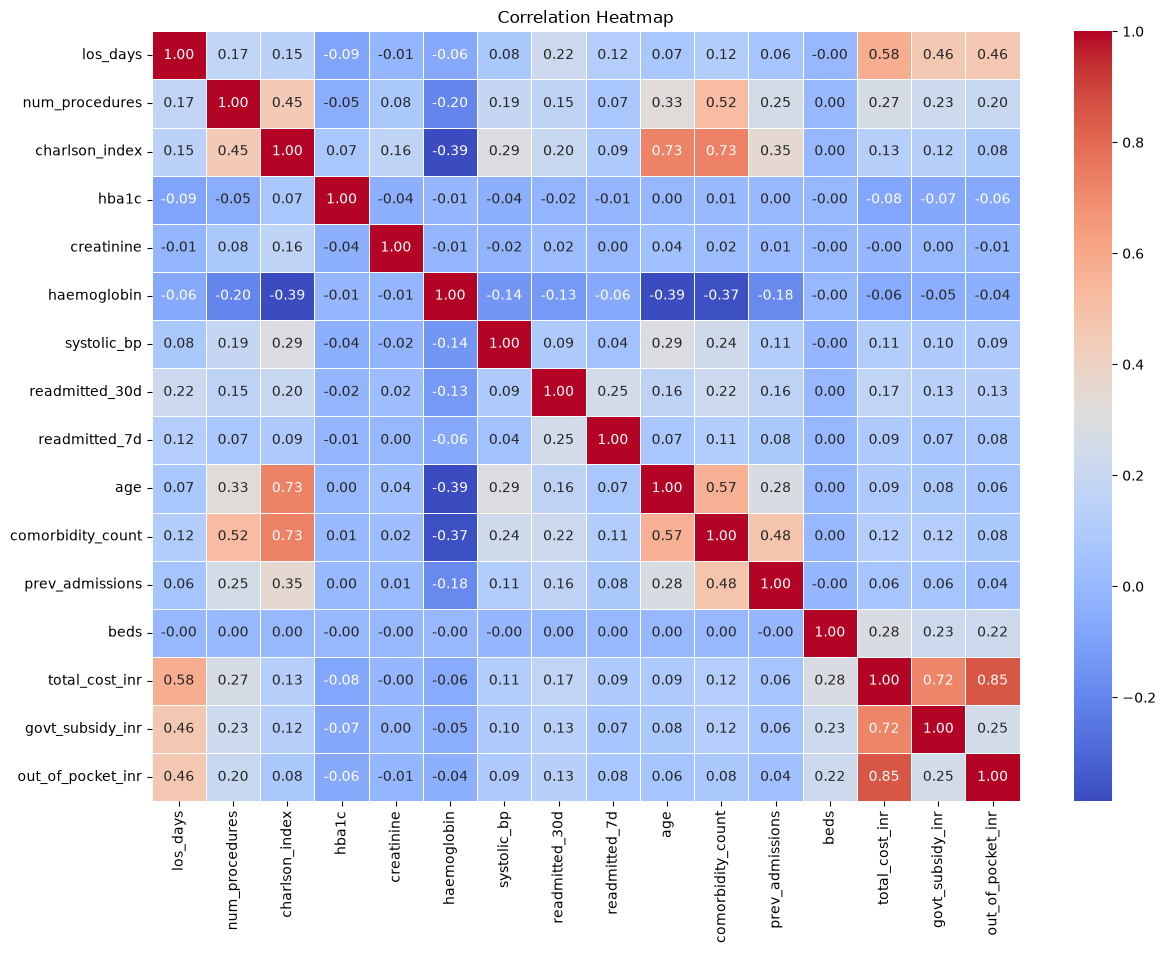

In [292]:

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [293]:

corr_matrix["readmitted_30d"].sort_values(ascending=False)

readmitted_30d       1.000000
readmitted_7d        0.250878
los_days             0.218204
comorbidity_count    0.217649
charlson_index       0.199160
total_cost_inr       0.167046
prev_admissions      0.158402
age                  0.156359
num_procedures       0.154993
govt_subsidy_inr     0.134149
out_of_pocket_inr    0.131907
systolic_bp          0.090246
creatinine           0.021083
beds                 0.002330
hba1c               -0.015158
haemoglobin         -0.131524
Name: readmitted_30d, dtype: float64

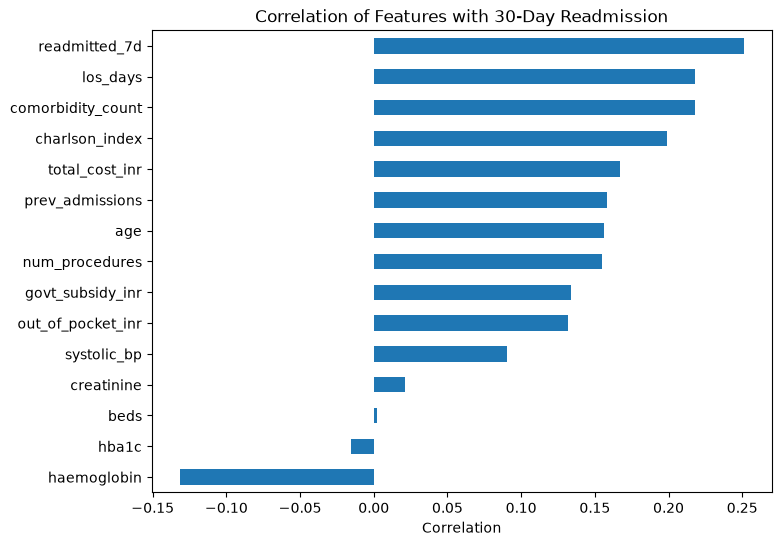

In [294]:

readmission_corr = (
    corr_matrix["readmitted_30d"]
    .drop("readmitted_30d")
    .sort_values()
)

plt.figure(figsize=(8,6))

readmission_corr.plot(kind="barh")

plt.title("Correlation of Features with 30-Day Readmission")

plt.xlabel("Correlation")

plt.show()

In [295]:

eda_df["admit_date"] = pd.to_datetime(eda_df["admit_date"])
eda_df["discharge_date"] = pd.to_datetime(eda_df["discharge_date"])

In [296]:

eda_df["admission_year"] = eda_df["admit_date"].dt.year

In [297]:

eda_df["admission_month"] = eda_df["admit_date"].dt.month_name()

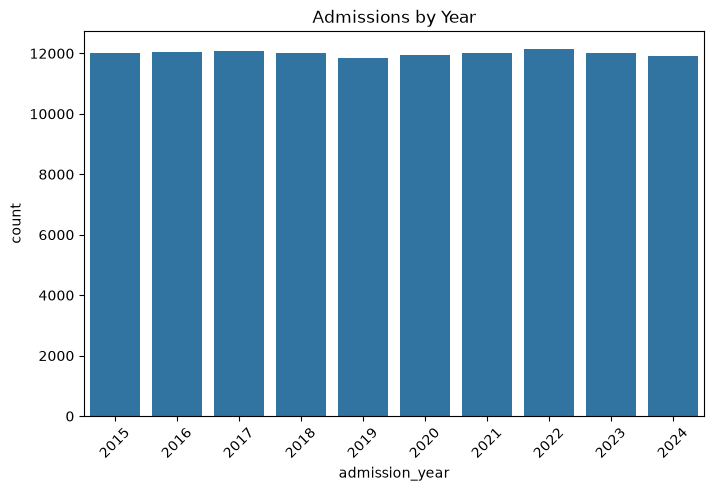

In [298]:

plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="admission_year"
)

plt.title("Admissions by Year")

plt.xticks(rotation=45)

plt.show()

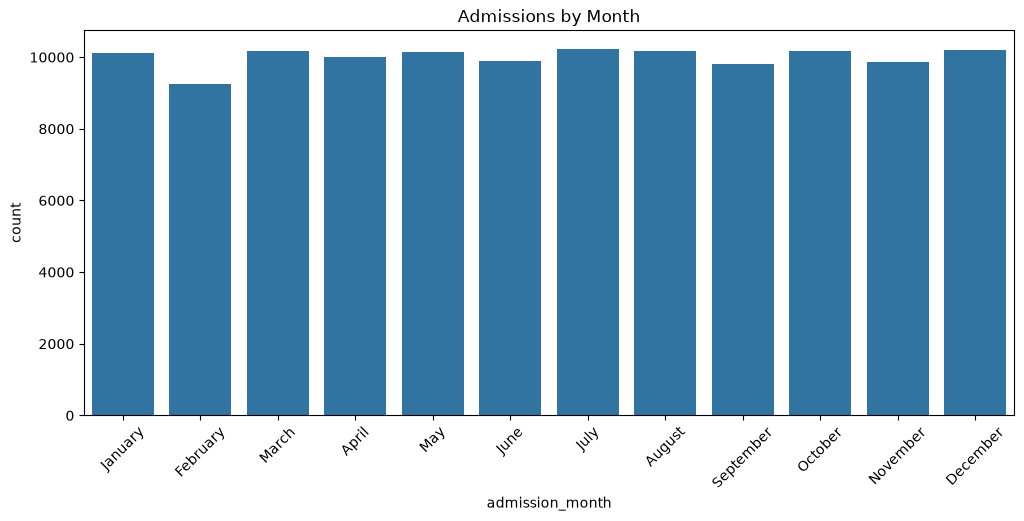

In [299]:

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=eda_df,
    x="admission_month",
    order=month_order
)

plt.title("Admissions by Month")

plt.xticks(rotation=45)

plt.show()

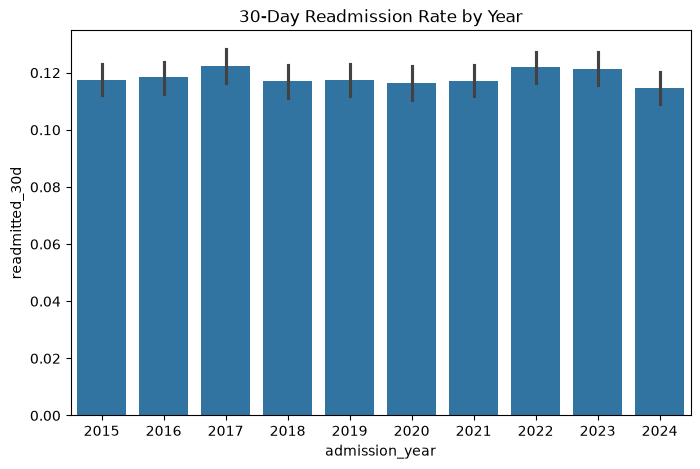

In [300]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=eda_df,
    x="admission_year",
    y="readmitted_30d",
    estimator=np.mean
)

plt.title("30-Day Readmission Rate by Year")

plt.show()

In [301]:

print("Merged Dataset Shape:", eda_df.shape)

print("\nMissing Values After Merge:")
print(eda_df.isnull().sum())

Merged Dataset Shape: (120000, 37)

Missing Values After Merge:
admission_id             0
patient_id               0
admit_date               0
discharge_date           0
los_days                 0
admit_type               0
ward_type                0
hospital_id              0
discharge_type           0
num_procedures           0
charlson_index           0
hba1c                    0
creatinine               0
haemoglobin              0
systolic_bp              0
readmitted_30d           0
readmitted_7d            0
age                      0
gender                   0
patient_state            0
bpl_card                 0
insurance_type       33987
comorbidity_count        0
prev_admissions          0
name                     0
hospital_state           0
tier                     0
beds                     0
teaching                 0
bill_id                  0
total_cost_inr           0
govt_subsidy_inr         0
out_of_pocket_inr        0
cost_category            0
age_group         